# Mean–variance analysis of the new ETF data

This notebook analyzes `fyqwk6gm8wvdj1fw.xlsx` and preserves the original `Project1.ipynb`. Run all cells from this folder to refresh the results.

**Method:** monthly simple returns as supplied in the workbook; historical arithmetic mean × 12; sample covariance × 12; annual volatility = monthly sample standard deviation × √12. Portfolios are fully invested and long-only, with no risk-free asset. These are in-sample historical estimates, not forecasts. No Sharpe ratio is reported because no risk-free series or assumption was supplied.

**Changes from the original:** map the new column names, join ticker changes by PERMNO, align dates by calendar month, audit data rather than silently discard extreme gains, solve the global minimum-variance (GMV) portfolio directly, and distinguish the efficient branch from the lower, inefficient branch. VOO is absent from this workbook; all seven available ETFs are investable.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.optimize import minimize
from IPython.display import display

INPUT_FILE = Path("fyqwk6gm8wvdj1fw.xlsx")
OUTPUT_DIR = Path("new_data_results")
OUTPUT_DIR.mkdir(exist_ok=True)
ANNUALIZATION_FACTOR = 12
N_FRONTIER_POINTS = 151
pd.set_option("display.max_columns", 20)


## 1. Load, identify securities, and audit

`Returns` is already a decimal monthly return; do not calculate percentage changes of this column or divide it by 100. PERMNO identifies a continuous security history even when its ticker changes. Each series is labelled with its latest ticker. Dates are normalized to calendar month-end. Conflicting duplicate observations cause an error; identical duplicate rows are removed. Missing returns are disclosed, and the analysis uses months common to all assets. Returns above 100% are flagged, not automatically deleted.

In [2]:
raw = pd.read_excel(INPUT_FILE)
raw.columns = raw.columns.str.strip()
required = {"PERMNO", "Names Date", "Ticker Symbol", "Returns"}
if not required.issubset(raw.columns):
    raise ValueError(f"Missing columns: {required - set(raw.columns)}")
df = raw.rename(columns={"Names Date": "Date", "Ticker Symbol": "Ticker", "Returns": "Return"}).copy()
if df[["PERMNO", "Date", "Ticker"]].isna().any().any():
    raise ValueError("Missing security identifiers, dates, or tickers")
df["Date"] = pd.to_datetime(df["Date"], errors="raise")
df["Ticker"] = df["Ticker"].astype(str).str.strip()
df["Return"] = pd.to_numeric(df["Return"], errors="raise")
if np.isinf(df["Return"].dropna()).any() or (df["Return"] < -1).any():
    raise ValueError("Invalid simple return (infinite or below -100%)")
df["Month"] = df["Date"].dt.to_period("M").dt.to_timestamp("M")
exact_duplicates = int(df.duplicated().sum())
df = df.drop_duplicates()
if df.duplicated(["PERMNO", "Month"]).any():
    raise ValueError("Multiple non-identical records for a security-month; inspect before proceeding")
labels = df.sort_values("Date").groupby("PERMNO")["Ticker"].last()
if labels.duplicated().any():
    raise ValueError("Latest ticker labels are not unique across securities")
identity = df.groupby(["PERMNO", "Ticker"]).agg(Start=("Month", "min"), End=("Month", "max"), Observations=("Return", "count")).reset_index()
identity["Analysis ticker"] = identity["PERMNO"].map(labels)
wide = df.pivot(index="Month", columns="PERMNO", values="Return").rename(columns=labels).sort_index()
wide = wide.reindex(pd.date_range(wide.index.min(), wide.index.max(), freq="M"))
wide.index.name = "Month"
wide.columns.name = "Ticker"
wide = wide.reindex(sorted(wide.columns), axis=1)
returns_wide = wide.dropna(how="any")
if len(returns_wide) < 24:
    raise ValueError("Fewer than 24 complete monthly observations")
if not returns_wide.index.to_period("M").equals(pd.period_range(returns_wide.index.min(), returns_wide.index.max(), freq="M")):
    raise ValueError("Common sample has gaps; resolve before reporting CAGR and drawdown")
audit = pd.DataFrame({"Value": [len(raw), exact_duplicates, int(df["Return"].isna().sum()), int((df["Return"] > 1).sum()), len(wide), len(wide)-len(returns_wide), len(returns_wide), returns_wide.shape[1]]}, index=["Raw rows", "Exact duplicates removed", "Missing returns", "Returns above 100% (retained)", "Calendar months", "Months excluded from common sample", "Common months", "Securities"])
display(audit, identity)
print(f"Common sample: {returns_wide.index.min():%Y-%m} through {returns_wide.index.max():%Y-%m}")


,Value
Raw rows,1260
Exact duplicates removed,0
Missing returns,0
Returns above 100% (retained),0
Calendar months,180
Months excluded from common sample,0
Common months,180
Securities,7


,PERMNO,Ticker,Start,End,Observations,Analysis ticker
0,86451,XLV,2010-01-31,2024-12-31,180,XLV
1,86452,XLP,2010-01-31,2024-12-31,180,XLP
2,86454,XLE,2010-01-31,2024-12-31,180,XLE
3,86455,XLF,2010-01-31,2024-12-31,180,XLF
4,86456,XLI,2010-01-31,2024-12-31,180,XLI
5,89060,IGV,2010-01-31,2024-12-31,180,IGV
6,89061,IGW,2010-01-31,2010-09-30,9,SOXX
7,89061,SOXX,2010-10-31,2024-12-31,171,SOXX


Common sample: 2010-01 through 2024-12


## 2. Asset metrics and diversification

The frontier uses **annualized arithmetic means**, not CAGR. CAGR compounds the monthly returns over the sample. Maximum drawdown is the worst decline from a preceding wealth peak, including an initial wealth of 1 before the first return; it is displayed as a negative number. Covariance uses the sample estimator (ddof = 1).

In [3]:
mu = returns_wide.mean() * ANNUALIZATION_FACTOR
cov = returns_wide.cov() * ANNUALIZATION_FACTOR
corr = returns_wide.corr()
std = pd.Series(np.sqrt(np.diag(cov)), index=mu.index)

def performance(series):
    a = np.asarray(series, dtype=float)
    wealth = np.r_[1.0, np.cumprod(1 + a)]
    return {"CAGR": wealth[-1] ** (12 / len(a)) - 1,
            "Cumulative return": wealth[-1] - 1,
            "Max drawdown": np.min(wealth / np.maximum.accumulate(wealth) - 1)}

summary = pd.DataFrame({"Months": len(returns_wide), "Monthly mean": returns_wide.mean(), "Monthly volatility": returns_wide.std(ddof=1), "Annualized mean": mu, "Annualized volatility": std})
summary = summary.join(pd.DataFrame({t: performance(returns_wide[t]) for t in mu.index}).T)
summary["Worst month"] = returns_wide.min()
summary["Best month"] = returns_wide.max()
display(summary.style.format({c: "{:.2%}" for c in summary.columns if c != "Months"}).format({"Months": "{:.0f}"}))
print("Correlation matrix")
display(corr.round(3))
print("Annualized covariance matrix (decimal return squared)")
display(cov.round(6))


,Months,Monthly mean,Monthly volatility,Annualized mean,Annualized volatility,CAGR,Cumulative return,Max drawdown,Worst month,Best month
Ticker,,,,,,,,,,
IGV,180,0.014947,0.055927,0.179367,0.193738,0.173363,10.002356,-0.430256,-0.130428,0.161565
SOXX,180,0.017760,0.069622,0.213122,0.241178,0.200722,14.546642,-0.406805,-0.178115,0.188526
XLE,180,0.008021,0.077950,0.096251,0.270027,0.061551,1.449700,-0.641079,-0.345576,0.307639
XLF,180,0.010945,0.054886,0.131344,0.190129,0.119265,4.419944,-0.318411,-0.211008,0.168483
XLI,180,0.011624,0.051895,0.139492,0.179771,0.130633,5.307025,-0.272308,-0.187113,0.160274
XLP,180,0.008911,0.034636,0.106930,0.119981,0.104482,3.439984,-0.136256,-0.089158,0.104307
XLV,180,0.010470,0.038867,0.125643,0.134640,0.123118,4.706626,-0.131861,-0.093673,0.125875


Correlation matrix


Ticker,IGV,SOXX,XLE,XLF,XLI,XLP,XLV
Ticker,,,,,,,
IGV,1.000,0.742,0.432,0.648,0.720,0.451,0.595
SOXX,0.742,1.000,0.460,0.652,0.723,0.426,0.528
XLE,0.432,0.460,1.000,0.710,0.689,0.426,0.470
XLF,0.648,0.652,0.710,1.000,0.875,0.568,0.652
XLI,0.720,0.723,0.689,0.875,1.000,0.684,0.717
XLP,0.451,0.426,0.426,0.568,0.684,1.000,0.711
XLV,0.595,0.528,0.470,0.652,0.717,0.711,1.000


Annualized covariance matrix (decimal return squared)


Ticker,IGV,SOXX,XLE,XLF,XLI,XLP,XLV
Ticker,,,,,,,
IGV,0.037534,0.034681,0.022612,0.023874,0.025073,0.010495,0.015531
SOXX,0.034681,0.058167,0.029976,0.029902,0.031348,0.012339,0.017142
XLE,0.022612,0.029976,0.072914,0.036460,0.033424,0.013801,0.017086
XLF,0.023874,0.029902,0.036460,0.036149,0.029919,0.012955,0.016682
XLI,0.025073,0.031348,0.033424,0.029919,0.032318,0.014757,0.017343
XLP,0.010495,0.012339,0.013801,0.012955,0.014757,0.014395,0.011482
XLV,0.015531,0.017142,0.017086,0.016682,0.017343,0.011482,0.018128


## 3. Optimize the portfolios

For weights $w$, portfolio mean is $w^T\mu$ and variance is $w^T\Sigma w$. Minimize variance subject to $\sum_i w_i=1$ and $0\leq w_i\leq1$. For the frontier, also require a chosen target return. The GMV is solved without a target-return constraint. The efficient branch starts at the GMV and extends to the highest feasible mean. Every numerical solution is checked for success, weight constraints, and target accuracy.

The equal-weight comparison assumes monthly rebalancing. GMV portfolio CAGR and drawdown also assume monthly rebalancing to the fixed estimated weights, with no trading costs. Weights are estimated using the full sample, so this is not an out-of-sample strategy backtest.

In [4]:
m = mu.to_numpy()
C = cov.to_numpy()
n = len(m)
if np.linalg.eigvalsh(C).min() < -1e-10:
    raise ValueError("Covariance is not positive semidefinite")

def solve_portfolio(target=None):
    constraints = [{"type": "eq", "fun": lambda w: w.sum()-1, "jac": lambda w: np.ones(n)}]
    w0 = np.ones(n)/n
    if target is not None:
        constraints.append({"type": "eq", "fun": lambda w: w @ m-target, "jac": lambda w: m})
        low, high = np.argmin(m), np.argmax(m)
        if m[high] > m[low]:
            frac = (target-m[low])/(m[high]-m[low])
            w0 = np.zeros(n)
            w0[low], w0[high] = 1-frac, frac
    result = minimize(lambda w: w @ C @ w, w0, jac=lambda w: 2*C @ w,
                      bounds=[(0,1)]*n, constraints=constraints, method="SLSQP",
                      options={"ftol": 1e-12, "maxiter": 2000})
    w = result.x
    if not result.success:
        raise RuntimeError(f"Optimization failed at {target}: {result.message}")
    if abs(w.sum()-1) > 1e-7 or w.min() < -1e-7 or w.max() > 1+1e-7:
        raise RuntimeError("Portfolio violates weight constraints")
    if target is not None and abs(w @ m-target) > 1e-7:
        raise RuntimeError("Portfolio misses target return")
    return w

def point(w):
    return {"Return": w @ m, "StdDev": np.sqrt(w @ C @ w), **dict(zip(mu.index, w))}

gmv_weights = solve_portfolio()
gmv = pd.Series(point(gmv_weights), name="Global minimum variance")
targets = np.unique(np.r_[np.linspace(m.min(), m.max(), N_FRONTIER_POINTS), gmv["Return"]])
frontier = pd.DataFrame([point(solve_portfolio(float(t))) for t in targets])
frontier["Efficient"] = frontier["Return"] >= gmv["Return"] - 1e-9
weights = pd.DataFrame({"Global minimum variance": gmv_weights, "Equal weight": np.ones(n)/n}, index=mu.index)
portfolio_metrics = pd.DataFrame({name: {"Annualized mean": w.to_numpy() @ m, "Annualized volatility": np.sqrt(w.to_numpy() @ C @ w.to_numpy()), **performance(returns_wide @ w)} for name, w in weights.items()}).T
assert (frontier["StdDev"] >= gmv["StdDev"] - 1e-7).all()
assert np.isclose((returns_wide @ gmv_weights).std(ddof=1)*np.sqrt(12), gmv["StdDev"])
# Independent first-order optimality check for the convex GMV problem.
grad = 2*C @ gmv_weights
assert grad.min() - gmv_weights @ grad >= -1e-6
print(f"Validated {len(frontier)} frontier portfolios and the directly optimized GMV.")
display(portfolio_metrics.style.format("{:.2%}"), weights.style.format("{:.2%}"))


Validated 152 frontier portfolios and the directly optimized GMV.


,Annualized mean,Annualized volatility,CAGR,Cumulative return,Max drawdown
Global minimum variance,11.61%,11.58%,11.51%,412.57%,-13.72%
Equal weight,14.17%,15.54%,13.77%,592.89%,-23.89%


,Global minimum variance,Equal weight
Ticker,,
IGV,6.07%,14.29%
SOXX,0.00%,14.29%
XLE,0.00%,14.29%
XLF,0.00%,14.29%
XLI,0.00%,14.29%
XLP,68.50%,14.29%
XLV,25.42%,14.29%


## 4. Mean–variance frontier

The horizontal axis shows annualized standard deviation, the conventional risk axis for a mean–variance frontier. The solid branch is efficient: no feasible portfolio has a higher estimated mean at the same or lower risk. The dashed lower branch is minimum-variance for its target return, but is dominated by portfolios above it.

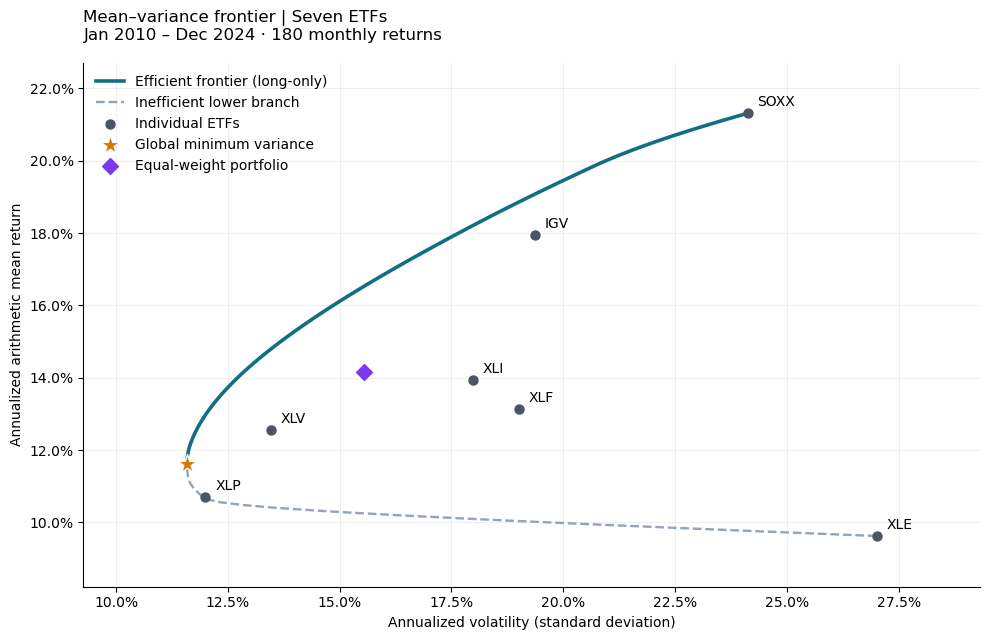

In [5]:
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
fig, ax = plt.subplots(figsize=(10, 6.5))
efficient = frontier[frontier["Efficient"]]
lower = frontier[frontier["Return"] <= gmv["Return"] + 1e-9]
ax.plot(efficient["StdDev"], efficient["Return"], color="#126E82", lw=2.6, label="Efficient frontier (long-only)")
if len(lower) > 1:
    ax.plot(lower["StdDev"], lower["Return"], "--", color="#94A3B8", lw=1.7, label="Inefficient lower branch")
ax.scatter(std, mu, color="#4B5563", s=42, zorder=5, label="Individual ETFs")
for t in mu.index:
    ax.annotate(t, (std[t], mu[t]), xytext=(7, 5), textcoords="offset points")
ax.scatter(gmv["StdDev"], gmv["Return"], marker="*", s=210, color="#D97706", edgecolor="white", zorder=6, label="Global minimum variance")
eq = portfolio_metrics.loc["Equal weight"]
ax.scatter(eq["Annualized volatility"], eq["Annualized mean"], marker="D", s=65, color="#7C3AED", zorder=6, label="Equal-weight portfolio")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Annualized volatility (standard deviation)")
ax.set_ylabel("Annualized arithmetic mean return")
ax.set_title(f"Mean–variance frontier | Seven ETFs\n{returns_wide.index.min():%b %Y} – {returns_wide.index.max():%b %Y} · {len(returns_wide)} monthly returns", loc="left", pad=16)
ax.grid(alpha=.18)
ax.legend(loc="best", frameon=False)
ax.margins(x=.15, y=.12)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mean_variance_frontier.png", dpi=200)
fig.savefig(OUTPUT_DIR / "mean_variance_frontier.pdf")
plt.show()


## 5. Export full-precision results

CSV and Excel numeric returns/weights are decimals (0.10 = 10%). The workbook formats these as percentages for readability. The original Excel file and notebook are unchanged.

In [6]:
tables = {"asset_metrics": summary, "portfolio_metrics": portfolio_metrics, "portfolio_weights": weights,
          "correlation": corr, "annual_covariance": cov, "monthly_returns": returns_wide,
          "frontier": frontier, "data_audit": audit, "security_history": identity}
for name, table in tables.items():
    table.to_csv(OUTPUT_DIR / f"{name}.csv", index=name not in ["frontier", "security_history"])
with pd.ExcelWriter(OUTPUT_DIR / "analysis_results.xlsx", engine="openpyxl") as writer:
    for name, table in tables.items():
        include_index = name not in ["frontier", "security_history"]
        table.to_excel(writer, sheet_name=name, index=include_index)
        sheet = writer.sheets[name]
        sheet.freeze_panes = "B2"
        for column in sheet.columns:
            letter = column[0].column_letter
            sheet.column_dimensions[letter].width = min(35, max(15, len(str(column[0].value or ""))+3))
        if name in ["asset_metrics", "portfolio_metrics", "portfolio_weights", "monthly_returns", "frontier"]:
            for row in sheet.iter_rows(min_row=2):
                for cell in row:
                    header = sheet.cell(1, cell.column).value
                    if isinstance(cell.value, (float, int)) and not isinstance(cell.value, bool) and header != "Months":
                        cell.number_format = "0.00%"
print(f"Results saved in {OUTPUT_DIR.resolve()}")


Results saved in C:\Users\samay\Documents\School\3B\CFM301\new_data_results
